# Punto 1: Alfa–Beta para tres en raya

`X` es MAX y `O` es MIN. Victoria de `X`: `+1`. Empate: `0`. Victoria de `O`: `-1`. Alfa–Beta devuelve el mismo valor que Minimax. La diferencia es cuántos nodos visita: si `α ≥ β`, se corta la rama.

In [1]:
from math import inf
from pathlib import Path

from IPython.display import display
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

In [2]:
# Índices de las ocho líneas que ganan: filas, columnas y diagonales.
LINEAS = [
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8),
    (0, 3, 6),
    (1, 4, 7),
    (2, 5, 8),
    (0, 4, 8),
    (2, 4, 6),
]

CARPETA_IMAGENES = Path("../../results/alpha-beta-pruning/images")
CARPETA_IMAGENES.mkdir(parents=True, exist_ok=True)


def acciones(tablero):
    return [indice for indice, casilla in enumerate(tablero) if casilla == " "]


def resultado(tablero, accion, jugador):
    nuevo = list(tablero)
    nuevo[accion] = jugador
    return tuple(nuevo)


def ganador(tablero):
    for a, b, c in LINEAS:
        if tablero[a] != " " and tablero[a] == tablero[b] == tablero[c]:
            return tablero[a]
    return None


def linea_ganadora(tablero):
    for a, b, c in LINEAS:
        if tablero[a] != " " and tablero[a] == tablero[b] == tablero[c]:
            return (a, b, c)
    return None


def terminal(tablero):
    return ganador(tablero) is not None or " " not in tablero


def utilidad(tablero):
    quien = ganador(tablero)
    if quien == "X":
        return 1
    if quien == "O":
        return -1
    return 0

In [3]:
def mostrar_tablero(tablero, titulo="Tablero", archivo=None):
    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect("equal")
    ax.axis("off")

    for i in range(4):
        ax.plot([i, i], [0, 3], color="black", linewidth=1.5)
        ax.plot([0, 3], [i, i], color="black", linewidth=1.5)

    linea = linea_ganadora(tablero)
    colores = {"X": "#c6efce", "O": "#ffc7ce"}
    if linea:
        for indice in linea:
            fila, columna = divmod(indice, 3)
            ax.add_patch(
                Rectangle(
                    (columna, 2 - fila),
                    1,
                    1,
                    facecolor=colores[tablero[indice]],
                    edgecolor="none",
                    zorder=0,
                )
            )

    for indice, ficha in enumerate(tablero):
        fila, columna = divmod(indice, 3)
        x = columna + 0.5
        y = 2.5 - fila
        ax.text(x, y, ficha if ficha != " " else "", ha="center", va="center", fontsize=22)

    ax.set_title(titulo)
    if archivo:
        fig.savefig(archivo, bbox_inches="tight")
    display(fig)
    plt.close(fig)

In [4]:
def minimax_tictactoe_contando(tablero, es_max, estadisticas):
    estadisticas["visitados"] += 1

    if terminal(tablero):
        estadisticas["hojas"] += 1
        return utilidad(tablero)

    jugador = "X" if es_max else "O"
    valores = [
        minimax_tictactoe_contando(
            resultado(tablero, accion, jugador),
            not es_max,
            estadisticas,
        )
        for accion in acciones(tablero)
    ]
    return max(valores) if es_max else min(valores)

In [5]:
def alfa_beta_tictactoe(tablero, es_max, alfa=-inf, beta=inf):
    """
    Valor Alfa–Beta del tablero. es_max True significa que mueve X.
    Si alfa >= beta se corta la rama: no puede cambiar la decisión.
    """
    if terminal(tablero):
        return utilidad(tablero)

    jugador = "X" if es_max else "O"

    if es_max:
        valor = -inf
        for accion in acciones(tablero):
            hijo = resultado(tablero, accion, jugador)
            valor = max(
                valor,
                alfa_beta_tictactoe(hijo, False, alfa, beta),
            )
            alfa = max(alfa, valor)
            if alfa >= beta:
                break
        return valor

    valor = inf
    for accion in acciones(tablero):
        hijo = resultado(tablero, accion, jugador)
        valor = min(
            valor,
            alfa_beta_tictactoe(hijo, True, alfa, beta),
        )
        beta = min(beta, valor)
        if alfa >= beta:
            break
    return valor

In [6]:
def alfa_beta_tictactoe_contando(
    tablero,
    es_max,
    estadisticas,
    alfa=-inf,
    beta=inf,
):
    estadisticas["visitados"] += 1

    if terminal(tablero):
        estadisticas["hojas"] += 1
        return utilidad(tablero)

    jugador = "X" if es_max else "O"

    if es_max:
        valor = -inf
        for accion in acciones(tablero):
            hijo = resultado(tablero, accion, jugador)
            valor = max(
                valor,
                alfa_beta_tictactoe_contando(
                    hijo, False, estadisticas, alfa, beta
                ),
            )
            alfa = max(alfa, valor)
            if alfa >= beta:
                estadisticas["podas"] += 1
                break
        return valor

    valor = inf
    for accion in acciones(tablero):
        hijo = resultado(tablero, accion, jugador)
        valor = min(
            valor,
            alfa_beta_tictactoe_contando(
                hijo, True, estadisticas, alfa, beta
            ),
        )
        beta = min(beta, valor)
        if alfa >= beta:
            estadisticas["podas"] += 1
            break
    return valor

In [7]:
def mejor_jugada_alfa_beta_tictactoe(tablero, es_max=True):
    jugador = "X" if es_max else "O"
    mejor_valor = -inf if es_max else inf
    mejor_accion = None
    alfa = -inf
    beta = inf
    opciones = []

    for accion in acciones(tablero):
        hijo = resultado(tablero, accion, jugador)
        valor = alfa_beta_tictactoe(hijo, not es_max, alfa, beta)
        opciones.append((valor, accion))

        if es_max:
            if valor > mejor_valor:
                mejor_valor = valor
                mejor_accion = accion
            alfa = max(alfa, mejor_valor)
        else:
            if valor < mejor_valor:
                mejor_valor = valor
                mejor_accion = accion
            beta = min(beta, mejor_valor)

    return {
        "valor": mejor_valor,
        "accion": mejor_accion,
        "opciones": opciones,
    }

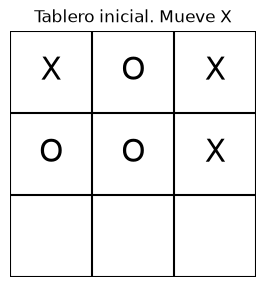

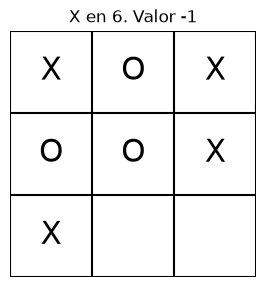

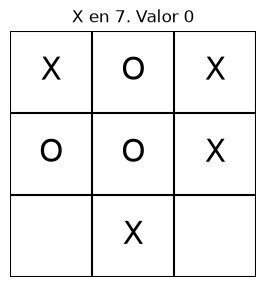

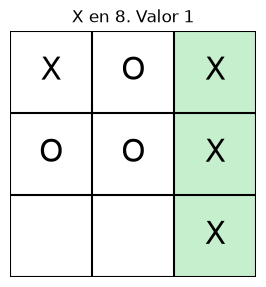

{'valor': 1, 'accion': 8, 'opciones': [(-1, 6), (0, 7), (1, 8)]}

In [8]:
tablero_arbol = (
    "X", "O", "X",
    "O", "O", "X",
    " ", " ", " ",
)

mostrar_tablero(
    tablero_arbol,
    "Tablero inicial. Mueve X",
    CARPETA_IMAGENES / "1-inicial.png",
)

jugada_arbol = mejor_jugada_alfa_beta_tictactoe(tablero_arbol, True)
for valor, accion in jugada_arbol["opciones"]:
    hijo = resultado(tablero_arbol, accion, "X")
    mostrar_tablero(
        hijo,
        f"X en {accion}. Valor {valor}",
        CARPETA_IMAGENES / f"1-x-en-{accion}.png",
    )

jugada_arbol

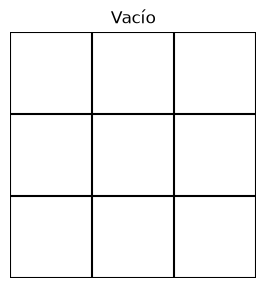

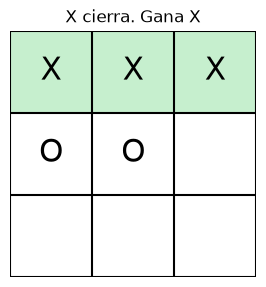

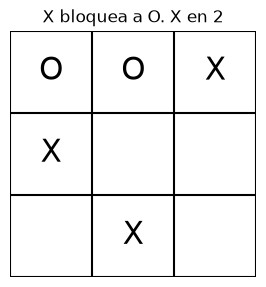

In [9]:
tablero_vacio = (
    " ", " ", " ",
    " ", " ", " ",
    " ", " ", " ",
)
tablero_cierra = (
    "X", "X", " ",
    "O", "O", " ",
    " ", " ", " ",
)
tablero_bloquea = (
    "O", "O", " ",
    "X", " ", " ",
    " ", "X", " ",
)

casos = {
    "Vacío": tablero_vacio,
    "X cierra": tablero_cierra,
    "X bloquea a O": tablero_bloquea,
}
archivos = {
    "Vacío": "1-vacio.png",
    "X cierra": "1-x-cierra.png",
    "X bloquea a O": "1-x-bloquea-a-o.png",
}

for nombre, tablero in casos.items():
    jugada = mejor_jugada_alfa_beta_tictactoe(tablero, True)
    hijo = resultado(tablero, jugada["accion"], "X")
    a_mostrar = tablero if nombre == "Vacío" else hijo
    titulo = nombre
    if ganador(hijo):
        titulo = f"{nombre}. Gana {ganador(hijo)}"
    elif nombre != "Vacío":
        titulo = f"{nombre}. X en {jugada['accion']}"
    mostrar_tablero(a_mostrar, titulo, CARPETA_IMAGENES / archivos[nombre])

In [10]:
tableros = {
    "Tres huecos": (
        "X", "O", "X",
        "O", "O", "X",
        " ", " ", " ",
    ),
    "Vacío": (
        " ", " ", " ",
        " ", " ", " ",
        " ", " ", " ",
    ),
    "X cierra": (
        "X", "X", " ",
        "O", "O", " ",
        " ", " ", " ",
    ),
    "X bloquea a O": (
        "O", "O", " ",
        "X", " ", " ",
        " ", "X", " ",
    ),
}

comparacion = {}
for nombre, tablero in tableros.items():
    stats_mm = {"visitados": 0, "hojas": 0}
    stats_ab = {"visitados": 0, "hojas": 0, "podas": 0}
    valor_mm = minimax_tictactoe_contando(tablero, True, stats_mm)
    valor_ab = alfa_beta_tictactoe_contando(tablero, True, stats_ab)
    jugada = mejor_jugada_alfa_beta_tictactoe(tablero, True)
    comparacion[nombre] = {
        "minimax": {"valor": valor_mm, **stats_mm},
        "alfa_beta": {"valor": valor_ab, **stats_ab},
        "accion": jugada["accion"],
    }

comparacion

{'Tres huecos': {'minimax': {'valor': 1, 'visitados': 11, 'hojas': 5},
  'alfa_beta': {'valor': 1, 'visitados': 11, 'hojas': 5, 'podas': 1},
  'accion': 8},
 'Vacío': {'minimax': {'valor': 0, 'visitados': 549946, 'hojas': 255168},
  'alfa_beta': {'valor': 0, 'visitados': 18297, 'hojas': 7330, 'podas': 8180},
  'accion': 0},
 'X cierra': {'minimax': {'valor': 1, 'visitados': 157, 'hojas': 73},
  'alfa_beta': {'valor': 1, 'visitados': 36, 'hojas': 13, 'podas': 16},
  'accion': 2},
 'X bloquea a O': {'minimax': {'valor': 1, 'visitados': 206, 'hojas': 92},
  'alfa_beta': {'valor': 1, 'visitados': 52, 'hojas': 20, 'podas': 17},
  'accion': 2}}

In [11]:
alfa_beta_tictactoe(tableros["Vacío"], True)

0